In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from adjustText import adjust_text
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
combined = pd.read_json(PROJECT_ROOT / "resultsv2" / "test_final_results.json")

table_results = combined[~combined["precision"].str.startswith("qat")].copy()
table_qat = combined[combined["precision"].str.startswith("qat")].copy()

COLS = 2
eb_kw = dict(capsize=3, capthick=0.8, elinewidth=0.8, linewidth=0)

BIT_PALETTE = {1: "#002B45", 2: "#009681", 4: "#239ED7", 8: "#8DB23E"}

PREC_ORDER = ["int4", "int8", "fp8", "fp16", "fp32"]

PREC_PALETTE = {
    "fp32": "#002B45", "fp16": "#239ED7", "fp8": "#009681",
    "int8": "#8DB23E", "int4": "#0E4B75",
    "qat_int8": "#D62728", "qat_int4": "#FF7F0E",
}

BACKEND_MARKERS = {"pytorch": "o", "tensorrt": "s"}
SCATTER_BIT_PALETTE = {1: "#002B45", 2: "#D62728", 4: "#239ED7", 8: "#8DB23E"}

QAT_PALETTE = {
    "qat_int8": "#009681", "qat_int4": "#FF7F0E",
    "int8": "#0E4B75", "int4": "#002B45",
}


def make_figure(title, n):
    nrows = math.ceil(n / COLS)
    fig, axes = plt.subplots(nrows, COLS, figsize=(4.5 * COLS, 3.8 * nrows),
                             constrained_layout=True, squeeze=False)
    fig.suptitle(title, fontsize=12, x=0.5, ha="center", y=1.04)
    fig.set_constrained_layout_pads(wspace=0.15, hspace=0.1)
    ax_flat = axes.flatten()
    for idx in range(n, len(ax_flat)):
        ax_flat[idx].set_visible(False)
    return ax_flat


def draw_bars(ax, grp, x_col, y_col, yerr_col, palette):
    x_vals = grp[x_col].tolist()
    x_pos = np.arange(len(x_vals))
    for xi, (_, row) in enumerate(grp.iterrows()):
        key = row[x_col] if isinstance(row[x_col], str) else int(row[x_col])
        c = palette.get(key, "#7f7f7f")
        ax.bar(xi, row[y_col], color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.errorbar(xi, row[y_col], yerr=row[yerr_col],
                    fmt="none", ecolor=c, **eb_kw)
        ax.text(xi, row[y_col] * 0.02, f"{row[y_col]:.3f}",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_ylim(0, (grp[y_col] + grp[yerr_col]).max() * 1.25)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)


print(f"table_results: {len(table_results)} rows, table_qat: {len(table_qat)} rows")

In [115]:
pd.read_json("../resultsv2/test_final_results.json")


,backend,precision,input_bits,top1_mean,top1_std,top5_mean,top5_std,infer_ms_mean,infer_ms_std
0,pytorch,fp16,8,77.975000,0.101,93.581000,0.237,3.048000,1.243958
1,pytorch,fp16,4,78.330000,0.369,93.642000,0.101,3.087000,1.243958
2,pytorch,fp16,2,76.888000,0.425,93.139000,0.053,3.075000,1.243958
3,pytorch,fp16,1,69.551000,0.475,89.477000,0.126,3.065000,1.243958
4,pytorch,fp32,8,77.988000,0.132,93.581000,0.232,3.043000,1.243958
5,pytorch,fp32,4,78.337000,0.332,93.655000,0.103,3.082000,1.243958
6,pytorch,fp32,2,76.861000,0.413,93.139000,0.053,2.984000,1.243958
7,pytorch,fp32,1,69.551000,0.466,89.470000,0.129,2.980000,1.243958
8,pytorch,qat_int4,8,77.102616,0.000,93.098592,0.000,9.398007,0.000000
9,pytorch,qat_int4,4,77.444668,0.000,93.118712,0.000,9.394407,0.000000


In [116]:
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.dpi"] = 150  # also makes inline display sharper


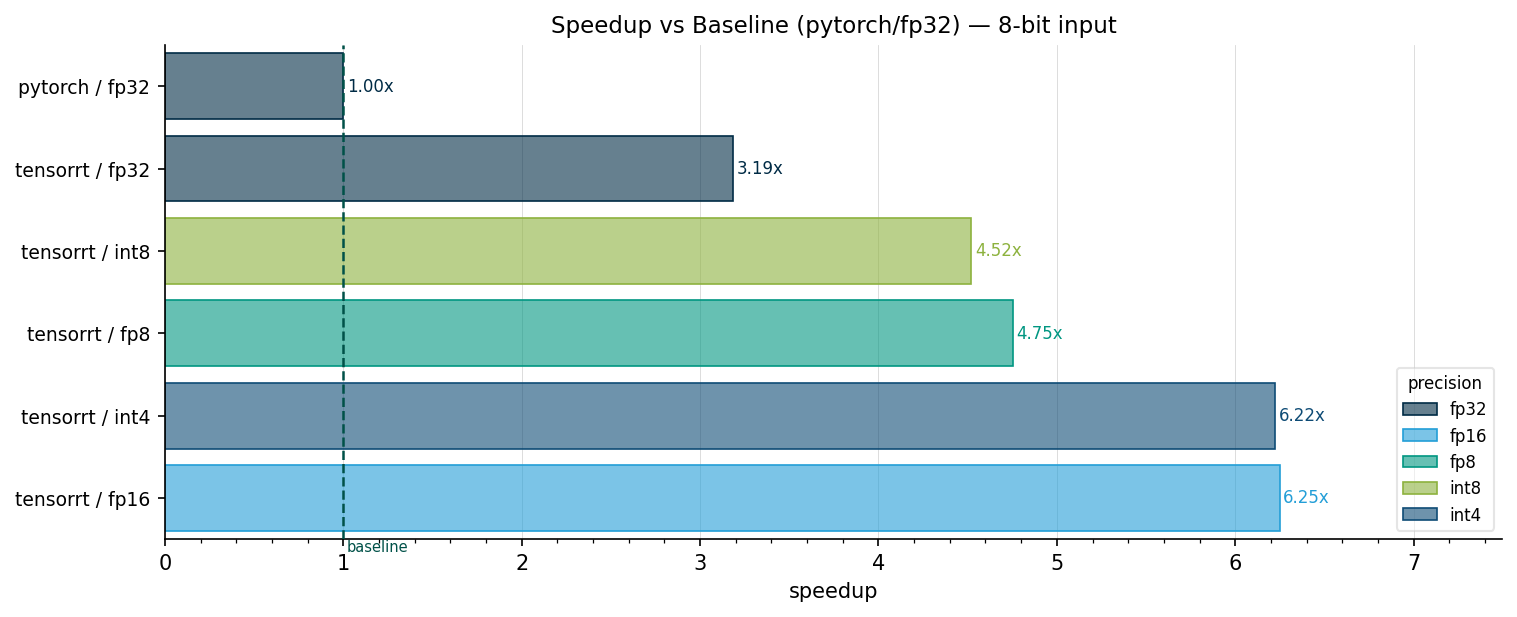

In [117]:
# Speedup plot — 8-bit input, selected configs
configs = [
    ("pytorch",  "fp32"),
    ("tensorrt", "fp32"),
    ("tensorrt", "int8"),
    ("tensorrt", "fp8"),
    ("tensorrt", "int4"),
    ("tensorrt", "fp16"),
]

rows = []
for backend, prec in configs:
    match = table_results[
        (table_results["backend"] == backend) &
        (table_results["precision"] == prec) &
        (table_results["input_bits"] == 8)
    ]
    if not match.empty:
        rows.append(match.iloc[0])

sub = pd.DataFrame(rows)
baseline_ms = sub[
    (sub["backend"] == "pytorch") & (sub["precision"] == "fp32")
]["infer_ms_mean"].values[0]

sub = sub.copy()
sub["speedup"] = baseline_ms / sub["infer_ms_mean"]
sub["label"] = sub["backend"] + " / " + sub["precision"]
sub = sub.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(sub) * 0.5 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(sub.iterrows()):
    color = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}x",
            ha="left", va="center", fontsize=8, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(1.02, len(sub) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(sub)))
ax.set_yticklabels(sub["label"], fontsize=9)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline (pytorch/fp32) — 8-bit input", fontsize=11)
ax.set_xlim(0, sub["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(sub) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_precs = [p for p in PREC_PALETTE if p in sub["precision"].values]
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=PREC_PALETTE[p] + "99",
                  edgecolor=PREC_PALETTE[p], linewidth=0.8, label=p)
    for p in present_precs
]
ax.legend(handles=handles, title="precision", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

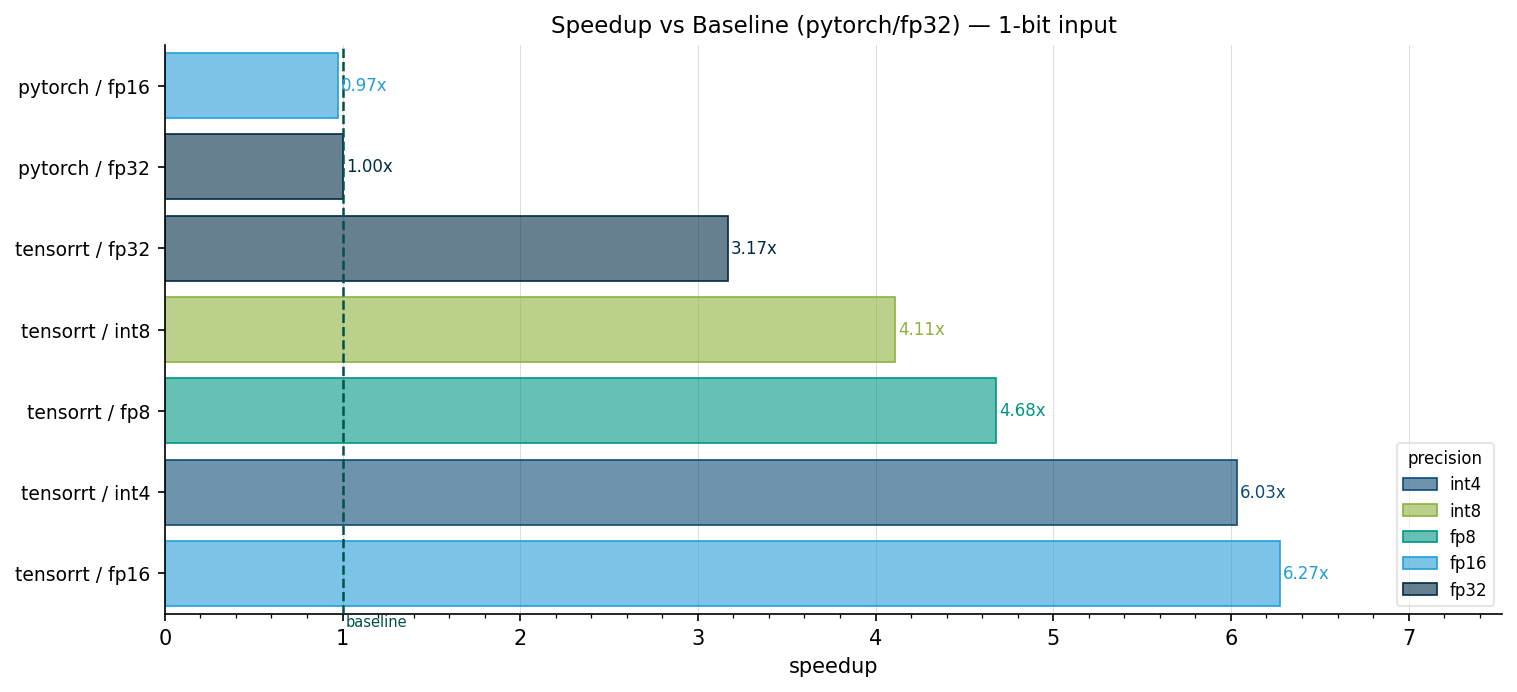

In [118]:
# Speedup plot — 1-bit input, all PTQ configs
configs_1b = [
    ("pytorch",  "fp32"),
    ("pytorch",  "fp16"),
    ("tensorrt", "fp32"),
    ("tensorrt", "fp16"),
    ("tensorrt", "fp8"),
    ("tensorrt", "int8"),
    ("tensorrt", "int4"),
]

rows_1b = []
for backend, prec in configs_1b:
    match = table_results[
        (table_results["backend"] == backend) &
        (table_results["precision"] == prec) &
        (table_results["input_bits"] == 1)
    ]
    if not match.empty:
        rows_1b.append(match.iloc[0])

sub_1b = pd.DataFrame(rows_1b)
baseline_ms_1b = sub_1b[
    (sub_1b["backend"] == "pytorch") & (sub_1b["precision"] == "fp32")
]["infer_ms_mean"].values[0]

sub_1b = sub_1b.copy()
sub_1b["speedup"] = baseline_ms_1b / sub_1b["infer_ms_mean"]
sub_1b["label"] = sub_1b["backend"] + " / " + sub_1b["precision"]
sub_1b = sub_1b.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(sub_1b) * 0.5 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(sub_1b.iterrows()):
    color = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}x",
            ha="left", va="center", fontsize=8, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(1.02, len(sub_1b) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(sub_1b)))
ax.set_yticklabels(sub_1b["label"], fontsize=9)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline (pytorch/fp32) — 1-bit input", fontsize=11)
ax.set_xlim(0, sub_1b["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(sub_1b) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_precs = [p for p in PREC_ORDER if p in sub_1b["precision"].values]
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=PREC_PALETTE[p] + "99",
                  edgecolor=PREC_PALETTE[p], linewidth=0.8, label=p)
    for p in present_precs
]
ax.legend(handles=handles, title="precision", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

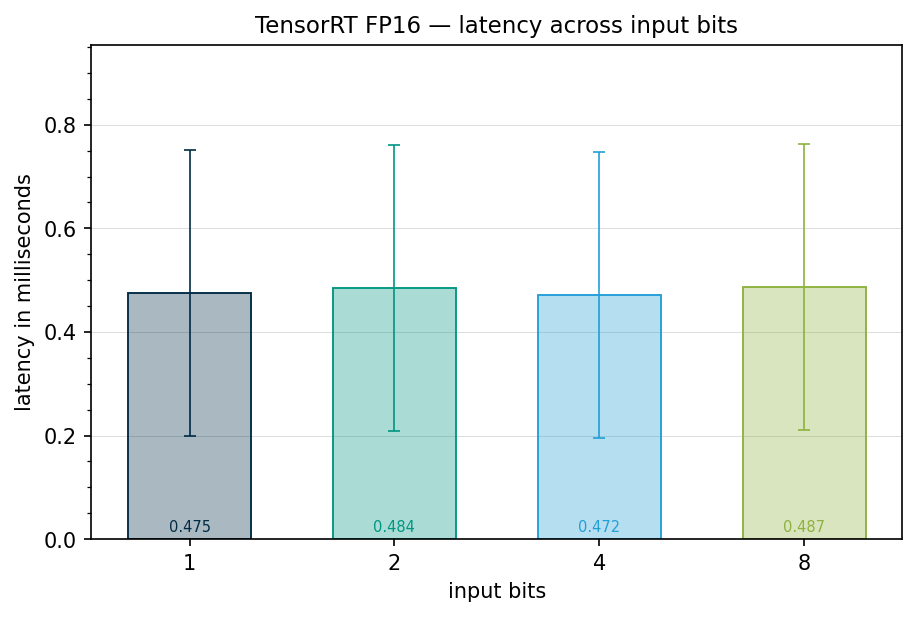

In [119]:
# FP16 model precision across all input bits — latency with error bars
fp16 = table_results[
    (table_results["backend"] == "tensorrt") & (table_results["precision"] == "fp16")
].sort_values("input_bits").copy()
fp16["input_bits"] = fp16["input_bits"].astype(int)

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

draw_bars(ax, fp16, "input_bits", "infer_ms_mean", "infer_ms_std", BIT_PALETTE)
ax.set_xlabel("input bits")
ax.set_ylabel("latency in milliseconds")
ax.set_title("TensorRT FP16 — latency across input bits", fontsize=11)

plt.show()

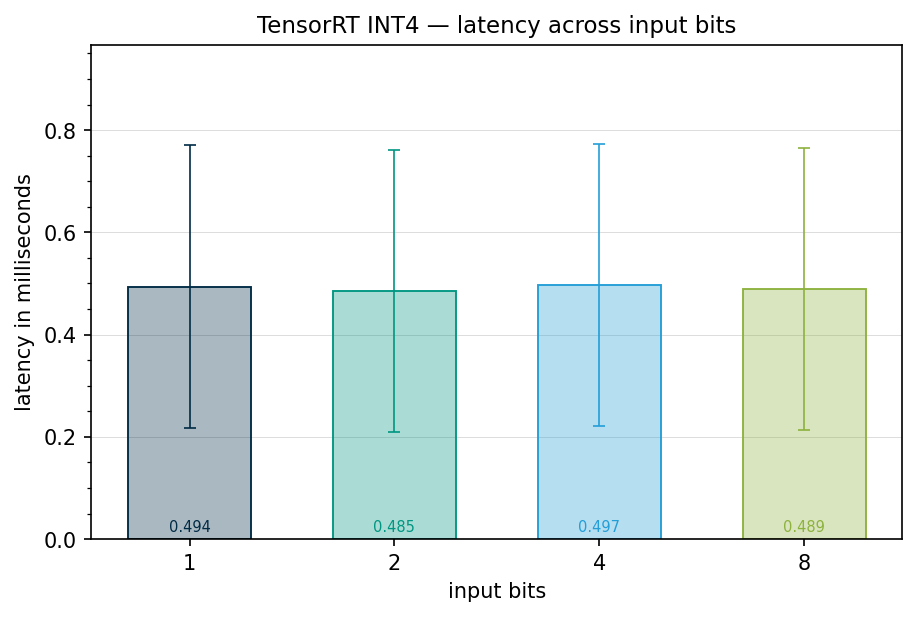

In [120]:
# INT4 model precision across all input bits — latency with error bars
int4 = table_results[
    (table_results["backend"] == "tensorrt") & (table_results["precision"] == "int4")
].sort_values("input_bits").copy()
int4["input_bits"] = int4["input_bits"].astype(int)

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

draw_bars(ax, int4, "input_bits", "infer_ms_mean", "infer_ms_std", BIT_PALETTE)
ax.set_xlabel("input bits")
ax.set_ylabel("latency in milliseconds")
ax.set_title("TensorRT INT4 — latency across input bits", fontsize=11)

plt.show()

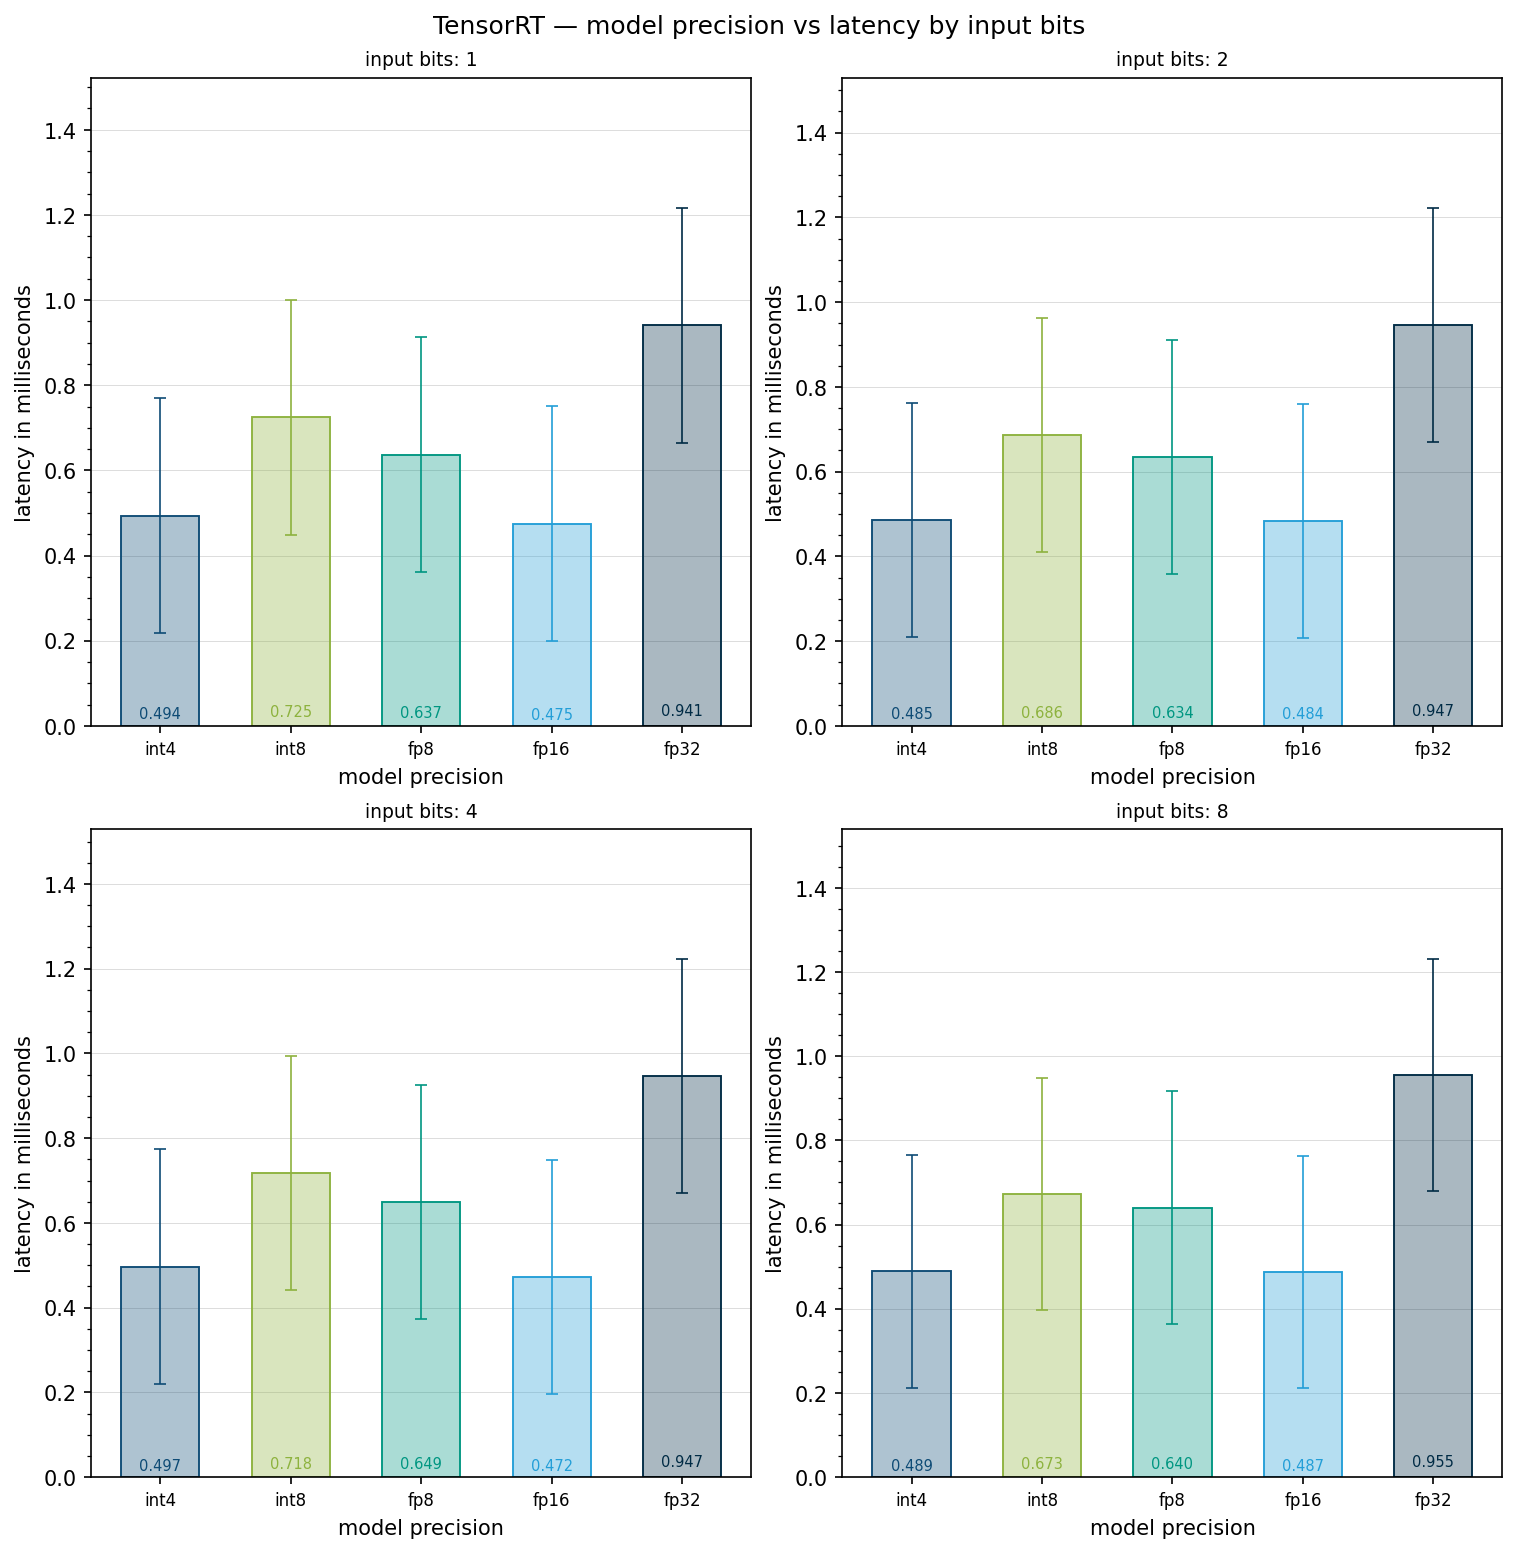

In [121]:
# 4 subplots: for each input bit-depth, model precision vs latency
trt = table_results[table_results["backend"] == "tensorrt"].copy()
trt["precision"] = pd.Categorical(trt["precision"], categories=PREC_ORDER, ordered=True)
active_bits = sorted(trt["input_bits"].astype(int).unique())

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
fig.suptitle("TensorRT — model precision vs latency by input bits", fontsize=12, y=1.02)

for ax, bits in zip(axes.flatten(), active_bits):
    grp = trt[trt["input_bits"] == bits].sort_values("precision").copy()

    x_pos = np.arange(len(grp))
    for xi, (_, row) in enumerate(grp.iterrows()):
        c = PREC_PALETTE.get(row["precision"], "#7f7f7f")
        ax.bar(xi, row["infer_ms_mean"], color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.errorbar(xi, row["infer_ms_mean"], yerr=row["infer_ms_std"],
                    fmt="none", ecolor=c, **eb_kw)
        ax.text(xi, row["infer_ms_mean"] * 0.02, f"{row['infer_ms_mean']:.3f}",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(grp["precision"].tolist(), fontsize=8)
    ax.set_xlabel("model precision")
    ax.set_ylabel("latency in milliseconds")
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.set_ylim(0, (grp["infer_ms_mean"] + grp["infer_ms_std"]).max() * 1.25)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

plt.show()

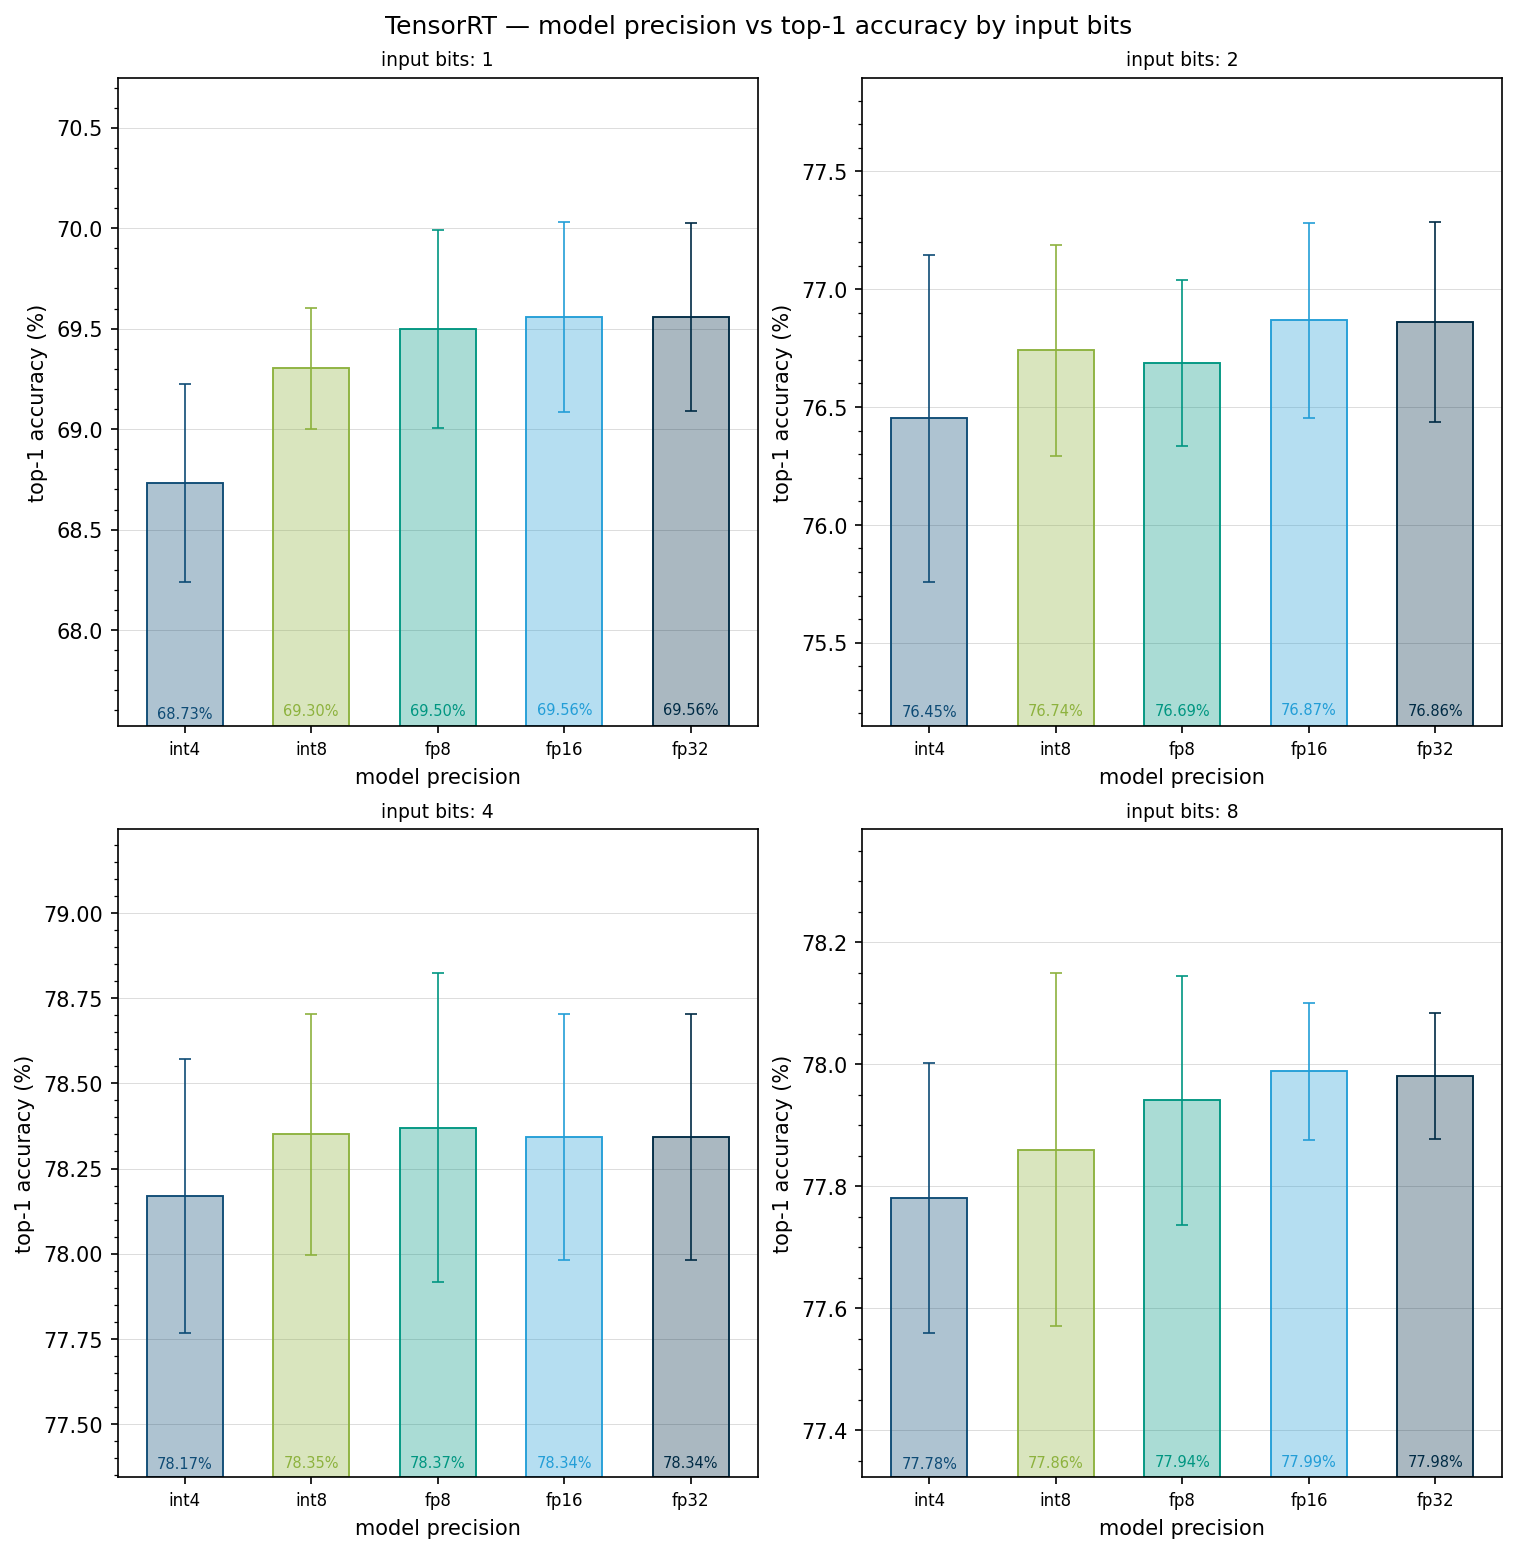

In [122]:
# 4 subplots: for each input bit-depth, model precision vs top-1 accuracy
trt_acc = table_results[table_results["backend"] == "tensorrt"].copy()
trt_acc["precision"] = pd.Categorical(trt_acc["precision"], categories=PREC_ORDER, ordered=True)
active_bits = sorted(trt_acc["input_bits"].astype(int).unique())

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
fig.suptitle("TensorRT — model precision vs top-1 accuracy by input bits", fontsize=12, y=1.02)

for ax, bits in zip(axes.flatten(), active_bits):
    grp = trt_acc[trt_acc["input_bits"] == bits].sort_values("precision").copy()

    ymin = (grp["top1_mean"] - grp["top1_std"]).min()
    ymax = (grp["top1_mean"] + grp["top1_std"]).max()
    margin = (ymax - ymin) * 0.4
    y_bottom = ymin - margin
    ax.set_ylim(y_bottom, ymax + margin)

    x_pos = np.arange(len(grp))
    for xi, (_, row) in enumerate(grp.iterrows()):
        c = PREC_PALETTE.get(row["precision"], "#7f7f7f")
        ax.bar(xi, row["top1_mean"] - y_bottom, bottom=y_bottom,
               color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.errorbar(xi, row["top1_mean"], yerr=row["top1_std"],
                    fmt="none", ecolor=c, **eb_kw)
        ax.text(xi, y_bottom + (row["top1_mean"] - y_bottom) * 0.02,
                f"{row['top1_mean']:.2f}%",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(grp["precision"].tolist(), fontsize=8)
    ax.set_xlabel("model precision")
    ax.set_ylabel("top-1 accuracy (%)")
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

plt.show()

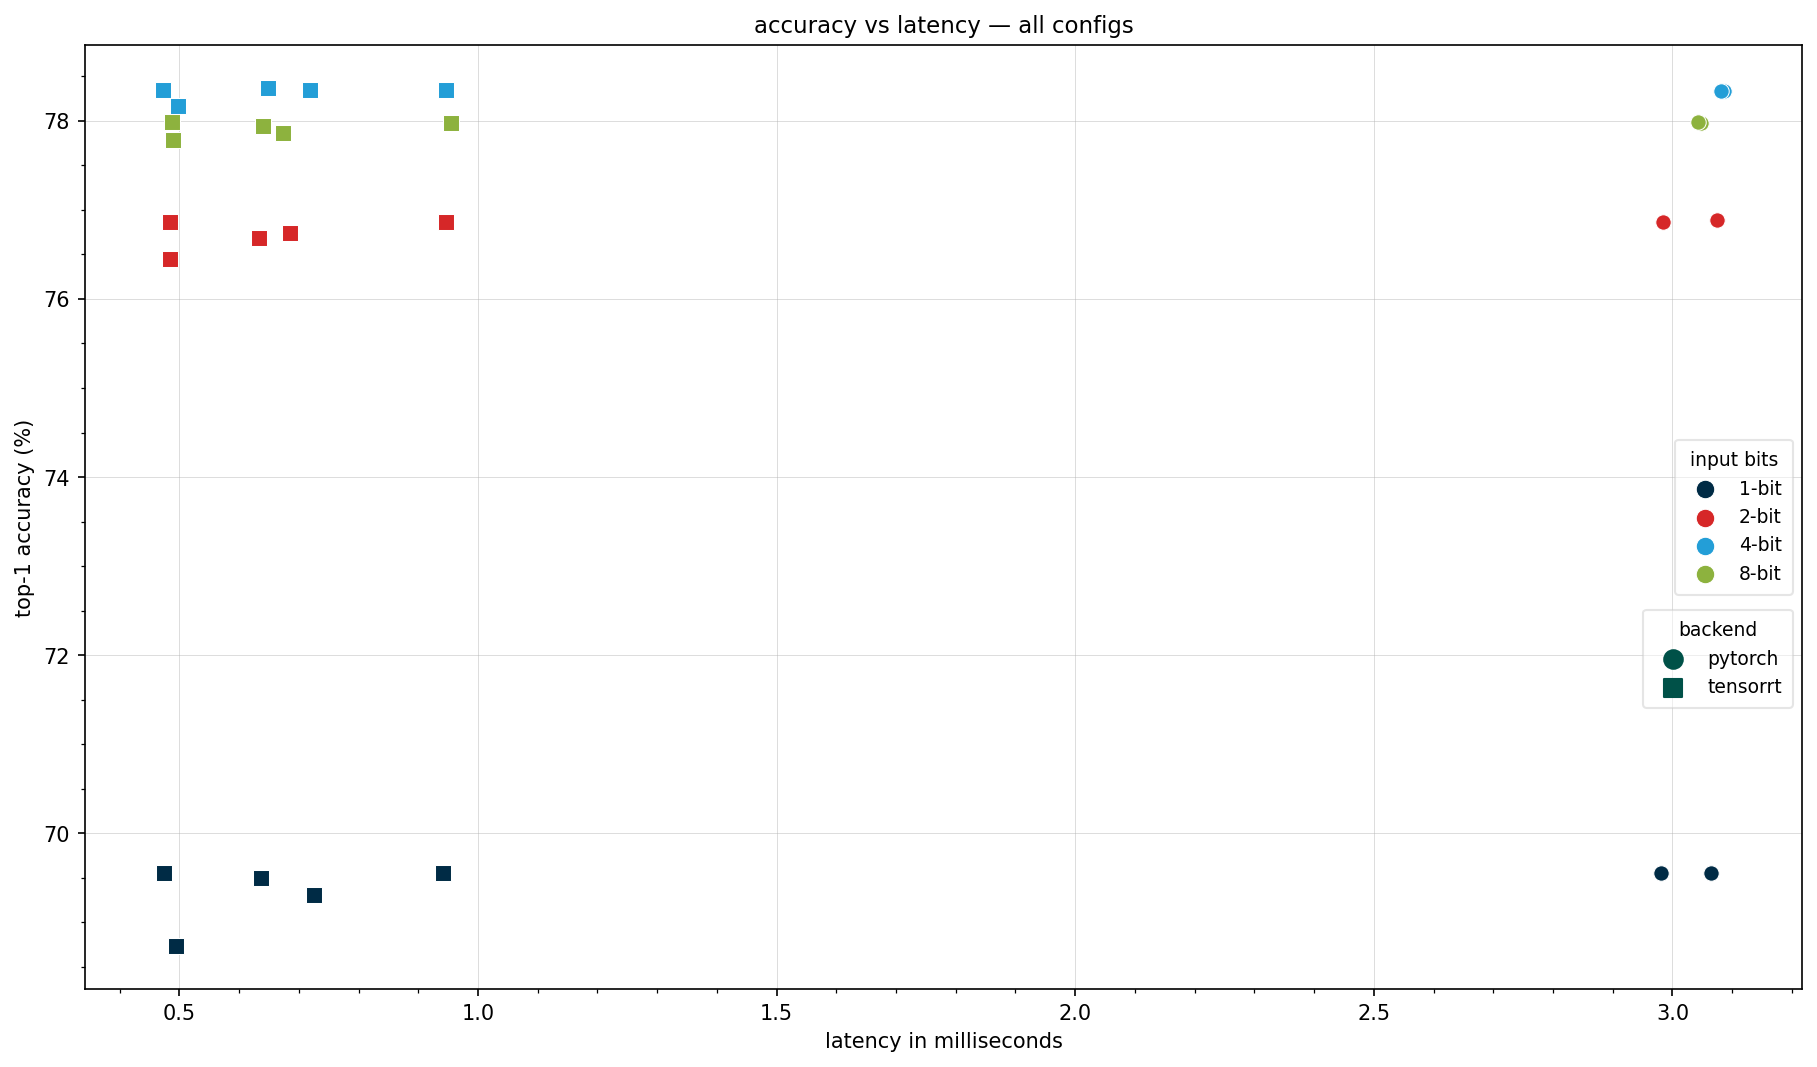

In [123]:
# Accuracy vs latency — all configs
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for backend, bgrp in table_results.groupby("backend"):
    marker = BACKEND_MARKERS.get(backend, "o")
    for _, row in bgrp.iterrows():
        bits = int(row["input_bits"])
        color = SCATTER_BIT_PALETTE.get(bits, "#7f7f7f")
        ax.scatter(row["infer_ms_mean"], row["top1_mean"],
                   color=color, marker=marker, s=55, edgecolors="white",
                   linewidths=0.5, zorder=3)

ax.set_xlabel("latency in milliseconds")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — all configs", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

legend_kw = dict(fontsize=9, title_fontsize=9, framealpha=0.5,
                 markerscale=1.2, handletextpad=0.8, borderpad=0.6)

bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=55, edgecolors="white",
                linewidths=0.5, label=f"{b}-bit")
    for b, c in SCATTER_BIT_PALETTE.items()
    if b in table_results["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits",
                    loc="center right", **legend_kw)
ax.add_artist(legend1)

backend_handles = [
    plt.scatter([], [], color="#005148", marker=m, s=55, label=b)
    for b, m in BACKEND_MARKERS.items()
]
ax.legend(handles=backend_handles, title="backend",
          bbox_to_anchor=(1, 0.35), loc="center right", **legend_kw)

plt.show()

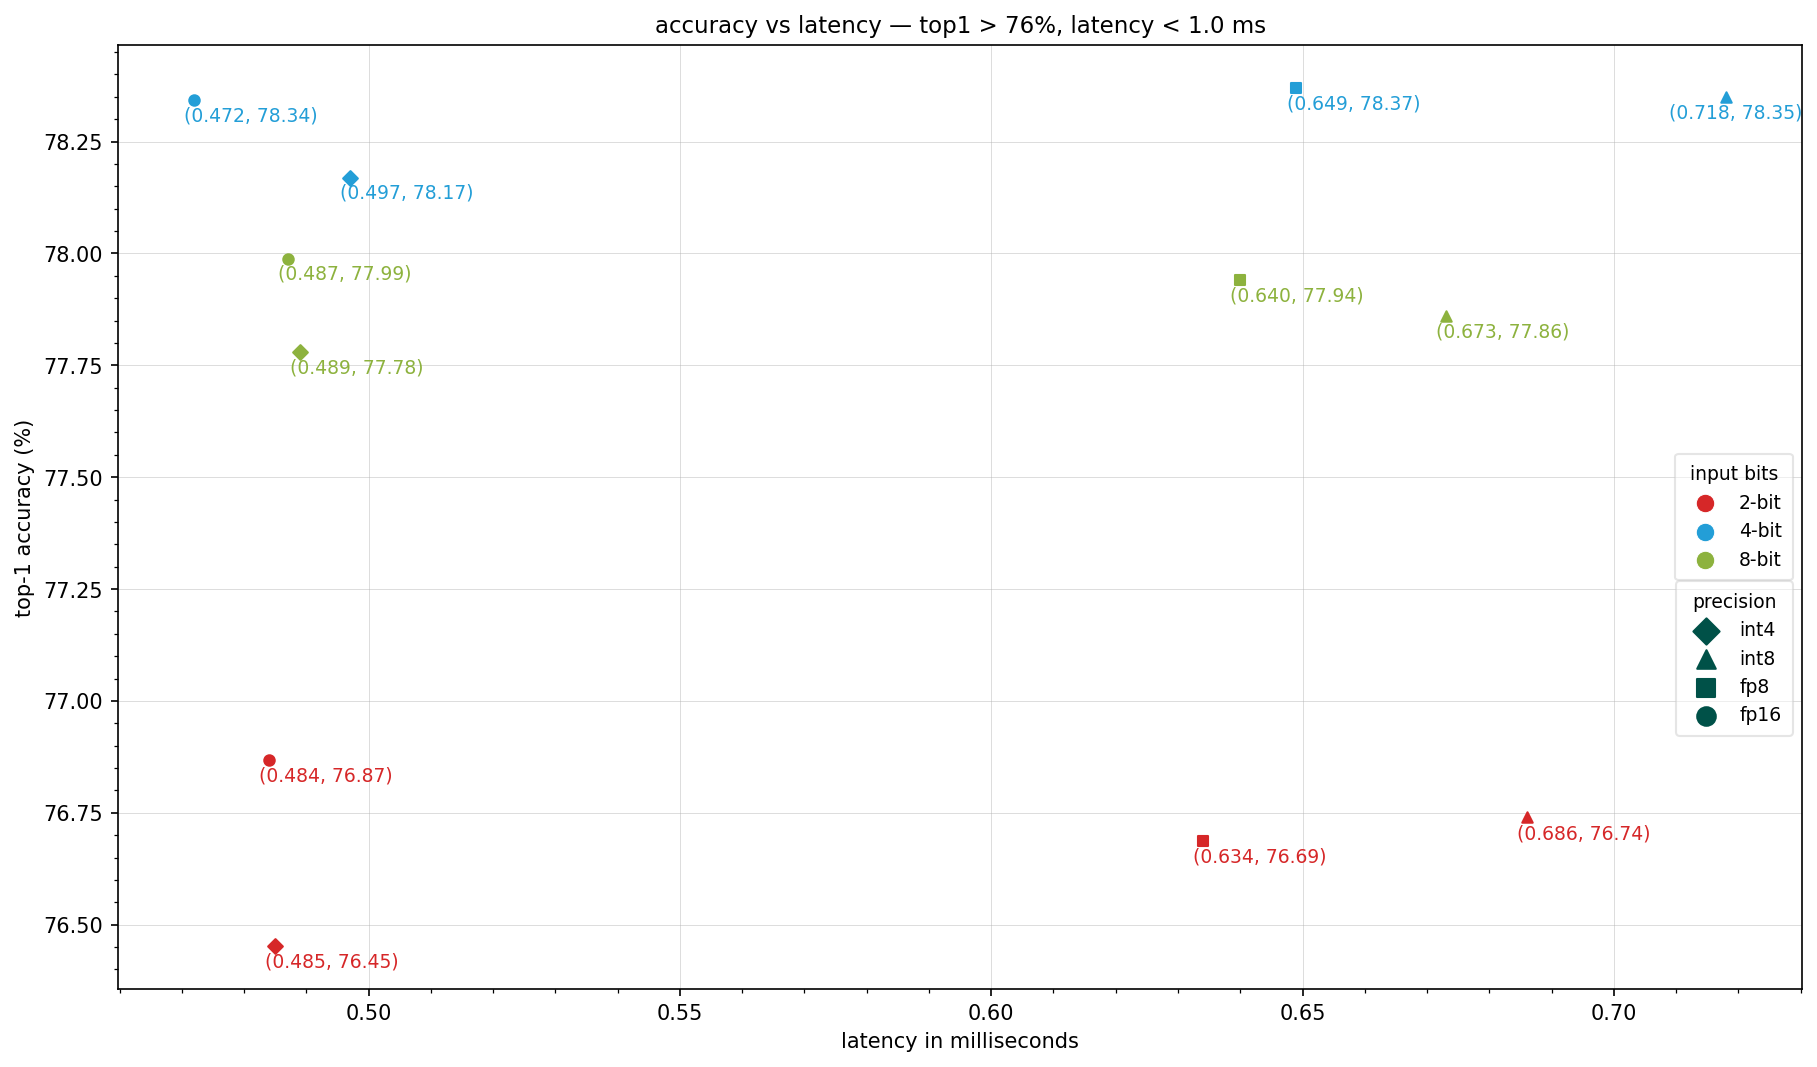

In [124]:
# Accuracy vs latency — zoomed (top1 > 76%, latency < 1.0 ms)
PREC_MARKERS = {"int4": "D", "int8": "^", "fp8": "s", "fp16": "o", "fp32": "P"}

filtered = table_results[
    (table_results["top1_mean"] > 76) & (table_results["infer_ms_mean"] < 1.0)
    & (table_results["precision"] != "fp32")
]

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

texts = []
for _, row in filtered.iterrows():
    bits = int(row["input_bits"])
    color = SCATTER_BIT_PALETTE.get(bits, "#7f7f7f")
    marker = PREC_MARKERS.get(row["precision"], "o")
    ax.scatter(row["infer_ms_mean"], row["top1_mean"],
               marker=marker, color=color, s=25, zorder=3)
    texts.append(ax.text(
        row["infer_ms_mean"], row["top1_mean"] - 0.01,
        f"({row['infer_ms_mean']:.3f}, {row['top1_mean']:.2f})",
        fontsize=9, color=color, ha="center", va="top",
    ))

ax.set_xlabel("latency in milliseconds")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — top1 > 76%, latency < 1.0 ms", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

adjust_text(
    texts, ax=ax,
    only_move={"text": "y", "static": "y", "explode": "y"},
    expand_points=(1.4, 2.0),
    expand_text=(1.2, 1.6),
)

legend_kw = dict(fontsize=9, title_fontsize=9, framealpha=0.5,
                 markerscale=1.2, handletextpad=0.8, borderpad=0.6)

bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=55, edgecolors="white",
                linewidths=0.5, label=f"{b}-bit")
    for b, c in SCATTER_BIT_PALETTE.items()
    if b in filtered["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits",
                    loc="center right", **legend_kw)
ax.add_artist(legend1)

prec_handles = [
    plt.scatter([], [], color="#005148", marker=PREC_MARKERS[p], s=55, label=p)
    for p in PREC_ORDER
    if p in filtered["precision"].values
]
ax.legend(handles=prec_handles, title="precision",
          bbox_to_anchor=(1, 0.35), loc="center right", **legend_kw)

plt.show()